# Aqui esta la historia de como se me fueron ocurriendo las cosas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

import seaborn as sns

from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn_extra.cluster import KMedoids

In [2]:
from scripts import style
style.mpl_apply()  

In [3]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')
materias_copy = materias.copy()

# Estandarizacion de la base de datos

En esta seccion se estandarizo la base de datos para que no haya alumnos repetidos que inflen la calificacion promedio de un profesor, o de una materia, etc. como los alumnos que revalidan materias y aparecen dos veces en la base de datos. Por ejemplo, yo salgo 2 veces en Calculo, 2 veces en Calculo II, etc.

In [4]:
print(materias.info())
materias.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27788 entries, 0 to 27787
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CLAVEALUMNO           27788 non-null  int64  
 1   CLAVECARRERA          27788 non-null  object 
 2   anio                  27788 non-null  int64  
 3   CLAVESESION           27788 non-null  object 
 4   NUMORDEN              27788 non-null  int64  
 5   CLAVEVARIANTEMATERIA  27788 non-null  object 
 6   DESCRIBEMATERIA       27788 non-null  object 
 7   CALIFICACION          27788 non-null  object 
 8   CLAVEPROFESOR         26740 non-null  float64
dtypes: float64(1), int64(3), object(5)
memory usage: 1.9+ MB
None


,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
1,165277,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,22473.0
2,162781,LII,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,22473.0
3,161869,LIM,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.9,22473.0
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0


Hay NaNs en los profes porque son de las revalidadas

In [5]:
def clean_materias_df(materias: pd.DataFrame) -> pd.DataFrame:
    # IF CLAVEPROFESOR is nan and 'CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION' are the same, drop that row
    materias.sort_values(by=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION', 'CLAVEPROFESOR'], inplace=True)
    materias.drop_duplicates(subset=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION'], keep='first', inplace=True, ignore_index=True)

    # drop NUMORDEN column
    materias.drop(columns=['NUMORDEN'], inplace=True)

    # drop the rows where CLAVEPROFESOR is nan
    materias.dropna(subset=['CLAVEPROFESOR'], inplace=True)
    # make the CLAVEPROFESOR column integer
    materias['CLAVEPROFESOR'] = materias['CLAVEPROFESOR'].astype(int)
    return materias

materias = clean_materias_df(materias)

In [6]:
materias.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152


In [7]:
def print_info():
    # clave profesor nunique
    profes_value_counts = materias['CLAVEPROFESOR'].value_counts()
    profes_ids = materias['CLAVEPROFESOR'].unique()
    print(f'Número de profesores únicos: {len(profes_ids)}')
    print(f'Número de calificaciones: {len(materias)}')
    print(f'Máximo de calificaciones por profesor: {profes_value_counts.max()}')
    print(f'Mínimo de calificaciones por profesor: {profes_value_counts.min()}')
    print(f'Promedio de calificaciones por profesor: {profes_value_counts.mean():.2f}')
    print(f'Desviación estándar de calificaciones por profesor: {profes_value_counts.std():.2f}')
    print(f'Mediana de calificaciones por profesor: {profes_value_counts.median():.2f}')
    print('-----------------------------------')

    # clave alumno nunique
    number_of_students = materias['CLAVEALUMNO'].value_counts()
    print(f'Número de estudiantes únicos: {len(number_of_students)}')
    print(f'Máximo de calificaciones por estudiante: {number_of_students.max()}')
    print(f'Mínimo de calificaciones por estudiante: {number_of_students.min()}')
    print(f'Promedio de calificaciones por estudiante: {number_of_students.mean():.2f}')
    print(f'Desviación estándar de calificaciones por estudiante: {number_of_students.std():.2f}')
    print(f'Mediana de calificaciones por estudiante: {number_of_students.median():.2f}')
    print('-----------------------------------')

        
    carreras = materias['CLAVECARRERA'].value_counts()
    print("Carreras y número de calificaciones:")
    print(carreras)
    print('-----------------------------------')

    # get info from the years
    years = materias['anio'].value_counts().sort_index()
    print("Años y número de calificaciones:")
    print(years)

    return profes_value_counts, profes_ids

profes_value_counts, profes_ids = print_info()

Número de profesores únicos: 77
Número de calificaciones: 26140
Máximo de calificaciones por profesor: 969
Mínimo de calificaciones por profesor: 26
Promedio de calificaciones por profesor: 339.48
Desviación estándar de calificaciones por profesor: 226.34
Mediana de calificaciones por profesor: 327.00
-----------------------------------
Número de estudiantes únicos: 10413
Máximo de calificaciones por estudiante: 13
Mínimo de calificaciones por estudiante: 1
Promedio de calificaciones por estudiante: 2.51
Desviación estándar de calificaciones por estudiante: 1.44
Mediana de calificaciones por estudiante: 2.00
-----------------------------------
Carreras y número de calificaciones:
CLAVECARRERA
LAD     1909
LNI     1892
LII     1805
LMT     1488
LAT     1289
        ... 
BQI        1
BMT        1
LNMM       1
BNM        1
LADM       1
Name: count, Length: 99, dtype: int64
-----------------------------------
Años y número de calificaciones:
anio
2019    4260
2020    4724
2021    4856
2022

In [8]:
import pandas as pd

def summarize_materias(materias: pd.DataFrame):
    """
    Imprime un resumen bastante completo del dataframe `materias`
    y devuelve un diccionario con varios resúmenes útiles.
    """

    print("========== RESUMEN GLOBAL ==========")
    print(f"Shape (filas, columnas): {materias.shape}")
    print("\nTipos de datos:")
    print(materias.dtypes)
    
    print("\nCardinalidad por columna (número de valores únicos):")
    print(materias.nunique())
    
    print("\nValores faltantes por columna:")
    print(materias.isna().sum())
    
    print("\nRango de años:")
    print(f"{materias['anio'].min()}  →  {materias['anio'].max()}")
    print("-----------------------------------")

    # ------------------------------------------------------
    # Limpieza de CALIFICACION: separar numéricas y no numéricas
    # ------------------------------------------------------
    calif_num = pd.to_numeric(materias['CALIFICACION'], errors='coerce')
    calif_no_num = materias.loc[calif_num.isna(), 'CALIFICACION'].value_counts()

    print("========== CALIFICACIÓN ==========")
    print("Resumen numérico (solo calificaciones que son números):")
    print(calif_num.describe())
    print("\nCalificaciones no numéricas (ej. RT, NA, etc.):")
    print(calif_no_num)
    print("-----------------------------------")

    # Guardar la versión numérica dentro del df para facilitar groupby
    materias = materias.copy()
    materias['CALIF_NUM'] = calif_num

    # ------------------------------------------------------
    # Profesores
    # ------------------------------------------------------
    print("========== PROFESORES ==========")
    profes_value_counts = materias['CLAVEPROFESOR'].value_counts()
    profes_ids = materias['CLAVEPROFESOR'].unique()

    print(f"Número de profesores únicos: {len(profes_ids)}")
    print(f"Número de calificaciones (registros): {len(materias)}")
    print(f"Máximo de calificaciones por profesor: {profes_value_counts.max()}")
    print(f"Mínimo de calificaciones por profesor: {profes_value_counts.min()}")
    print(f"Promedio de calificaciones por profesor: {profes_value_counts.mean():.2f}")
    print(f"Desviación estándar de calificaciones por profesor: {profes_value_counts.std():.2f}")
    print(f"Mediana de calificaciones por profesor: {profes_value_counts.median():.2f}")

    # Resumen por profesor: n, promedio, mediana, std de calificación numérica
    resumen_profes = (
        materias
        .groupby('CLAVEPROFESOR')
        .agg(
            n_registros=('CALIF_NUM', 'size'),
            n_calif_numericas=('CALIF_NUM', 'count'),
            calif_media=('CALIF_NUM', 'mean'),
            calif_mediana=('CALIF_NUM', 'median'),
            calif_std=('CALIF_NUM', 'std')
        )
        .sort_values('n_registros', ascending=False)
    )

    print("\nTop 5 profesores por número de registros:")
    print(resumen_profes.head(5))
    print("-----------------------------------")

    # ------------------------------------------------------
    # Estudiantes
    # ------------------------------------------------------
    print("========== ESTUDIANTES ==========")
    number_of_students = materias['CLAVEALUMNO'].value_counts()
    print(f"Número de estudiantes únicos: {len(number_of_students)}")
    print(f"Máximo de calificaciones por estudiante: {number_of_students.max()}")
    print(f"Mínimo de calificaciones por estudiante: {number_of_students.min()}")
    print(f"Promedio de calificaciones por estudiante: {number_of_students.mean():.2f}")
    print(f"Desviación estándar de calificaciones por estudiante: {number_of_students.std():.2f}")
    print(f"Mediana de calificaciones por estudiante: {number_of_students.median():.2f}")

    resumen_alumnos = (
        materias
        .groupby('CLAVEALUMNO')
        .agg(
            n_materias=('CALIF_NUM', 'size'),
            n_calif_numericas=('CALIF_NUM', 'count'),
            calif_media=('CALIF_NUM', 'mean'),
            calif_mediana=('CALIF_NUM', 'median'),
            calif_std=('CALIF_NUM', 'std')
        )
        .sort_values('n_materias', ascending=False)
    )

    print("\nTop 5 estudiantes por número de materias:")
    print(resumen_alumnos.head(5))
    print("-----------------------------------")

    # ------------------------------------------------------
    # Carreras
    # ------------------------------------------------------
    print("========== CARRERAS ==========")
    carreras = materias['CLAVECARRERA'].value_counts()
    print("Carreras y número de calificaciones:")
    print(carreras)

    # Calificación media por carrera
    calif_por_carrera = (
        materias
        .groupby('CLAVECARRERA')
        .agg(
            n_registros=('CALIF_NUM', 'size'),
            n_calif_numericas=('CALIF_NUM', 'count'),
            calif_media=('CALIF_NUM', 'mean'),
            calif_mediana=('CALIF_NUM', 'median')
        )
        .sort_values('n_registros', ascending=False)
    )
    print("\nResumen de calificación por carrera:")
    print(calif_por_carrera)
    print("-----------------------------------")

    # ------------------------------------------------------
    # Años y sesiones
    # ------------------------------------------------------
    print("========== AÑOS Y SESIONES ==========")
    years = materias['anio'].value_counts().sort_index()
    print("Años y número de calificaciones:")
    print(years)

    # Distribución por año y sesión (PRIMAVERA / OTOÑO, etc.)
    anio_sesion = (
        materias
        .groupby(['anio', 'CLAVESESION'])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    print("\nMatriz año × sesión (número de registros):")
    print(anio_sesion)
    print("-----------------------------------")

    # ------------------------------------------------------
    # Materias (CLAVEVARIANTEMATERIA + DESCRIBEMATERIA)
    # ------------------------------------------------------
    print("========== MATERIAS ==========")
    materias_resumen = (
        materias
        .groupby(['CLAVEVARIANTEMATERIA', 'DESCRIBEMATERIA'])
        .agg(
            n_registros=('CALIF_NUM', 'size'),
            n_calif_numericas=('CALIF_NUM', 'count'),
            calif_media=('CALIF_NUM', 'mean'),
            calif_mediana=('CALIF_NUM', 'median')
        )
        .sort_values('n_registros', ascending=False)
    )

    print("Top 10 materias por número de registros:")
    print(materias_resumen.head(10))
    print("-----------------------------------")

    # ------------------------------------------------------
    # Pivot carrera × año: cuántos registros
    # ------------------------------------------------------
    carrera_anio = materias.pivot_table(
        index='CLAVECARRERA',
        columns='anio',
        values='CLAVEALUMNO',
        aggfunc='count',
        fill_value=0
    ).sort_index()

    print("Matriz carrera × año (número de registros):")
    print(carrera_anio)
    print("-----------------------------------")

    # Devolver todo lo que podría ser útil para análisis posterior
    resultados = {
        "profes_value_counts": profes_value_counts,
        "profes_ids": profes_ids,
        "resumen_profes": resumen_profes,
        "students_value_counts": number_of_students,
        "resumen_alumnos": resumen_alumnos,
        "carreras_counts": carreras,
        "calif_por_carrera": calif_por_carrera,
        "years_counts": years,
        "anio_sesion": anio_sesion,
        "materias_resumen": materias_resumen,
        "carrera_anio": carrera_anio,
        "calif_num": calif_num,
        "calif_no_num": calif_no_num,
    }

    return resultados

# Uso:
# stats = summarize_materias(materias)
# profes_value_counts = stats["profes_value_counts"]
# profes_ids = stats["profes_ids"]


summarize_materias(materias)

========== RESUMEN GLOBAL ==========
Shape (filas, columnas): (26140, 8)

Tipos de datos:
CLAVEALUMNO              int64
CLAVECARRERA            object
anio                     int64
CLAVESESION             object
CLAVEVARIANTEMATERIA    object
DESCRIBEMATERIA         object
CALIFICACION            object
CLAVEPROFESOR            int32
dtype: object

Cardinalidad por columna (número de valores únicos):
CLAVEALUMNO             10413
CLAVECARRERA               99
anio                        7
CLAVESESION                 2
CLAVEVARIANTEMATERIA        7
DESCRIBEMATERIA             7
CALIFICACION              104
CLAVEPROFESOR              77
dtype: int64

Valores faltantes por columna:
CLAVEALUMNO             0
CLAVECARRERA            0
anio                    0
CLAVESESION             0
CLAVEVARIANTEMATERIA    0
DESCRIBEMATERIA         0
CALIFICACION            0
CLAVEPROFESOR           0
dtype: int64

Rango de años:
2019  →  2025
-----------------------------------
========== CALIFICACIÓ

{'profes_value_counts': CLAVEPROFESOR
 23452    969
 23411    772
 23152    726
 24097    720
 23852    719
         ... 
 24328     40
 21226     30
 22472     30
 21756     30
 26078     26
 Name: count, Length: 77, dtype: int64,
 'profes_ids': array([23453, 21815, 22109, 24085, 23152, 24097, 23162, 23425, 23885,
        21228, 23468, 23434, 23411, 22446, 22767, 25093, 20792, 22091,
        22115, 24117, 23149, 23824, 23133, 23836, 23096, 22471, 23874,
        23852, 21779, 23839, 23837, 22521, 22503, 23887, 21854, 21852,
        16164, 21756, 23452, 23823, 23897, 18269, 24086, 20566, 23978,
        21853, 23859, 21262, 22114, 20529, 22473, 23218, 15282, 23148,
        21226, 22474, 22480, 23799, 23442, 23835, 20530, 24013, 24510,
        21192, 25487, 23153, 12516, 24328, 24827, 25496, 25503, 25843,
        25494, 22472, 25531, 26078, 25510]),
 'resumen_profes':                n_registros  n_calif_numericas  calif_media  calif_mediana  \
 CLAVEPROFESOR                               

# Pruebas de Hipotesis

In [9]:
asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')

# count how many times each id appears in 'id' column
asesoria_counts = asesorias['id'].value_counts()

# if id in materias['CLAVEALUMNO'] but not in asesoria_counts, assign 0 in materias_counts
asesoria_counts = asesoria_counts.reindex(materias['CLAVEALUMNO'].unique(), fill_value=0)


In [10]:
asesorias.head()

,fecha,id,carrera,semestre,profesor,materia,tema,periodo
0,2024-02-08 10:06:02,0,Ingeniería Mecánica,2,Daniela Rodríguez Tzompantzi,Cálculo I,Derivadas,P
1,2023-08-14 10:02:28,0,Física,3,Azucena Tochimani Tiro,Cálculo II,Sucesiones y series,O
2,2022-01-03 09:15:51,0,Psicología Clínica,2,DIEGO RODRIGUEZ CENTENO,Estadística Para Ciencias Sociales,Probabilidad,P
3,2021-03-19 20:36:13,0,Ingeniería Industrial,2,Miguel Pérez Gaspar,Cálculo I,Derivadas,P
4,2020-09-21 16:01:13,0,Ingeniería en Sistemas Computacionales,1,Anel Vázquez Martínez,Matemáticas Universitarias,Conceptos fundamentales algebra,O


In [11]:
# asesorias counts, 0: 10123, 1: 2345, 2: 678, 3: 456, 4: 345, 5: 234, 6: 123, 7: 89, 8: 67, 9: 45, 10: 23
asesoria_counts.value_counts()

count
0      7488
1      1045
2       494
3       350
4       208
5       145
6       124
7       106
8        76
10       54
9        52
11       49
13       28
14       26
12       23
15       23
17       14
18       11
26       10
16        9
21        7
20        6
28        6
23        6
19        6
22        6
29        5
25        4
33        3
27        3
32        3
30        3
34        2
37        2
49        2
42        2
24        2
36        2
48        1
43        1
35        1
70        1
44        1
114       1
39        1
116       1
Name: count, dtype: int64

# Numero de visitas al CMAT por estudiante 

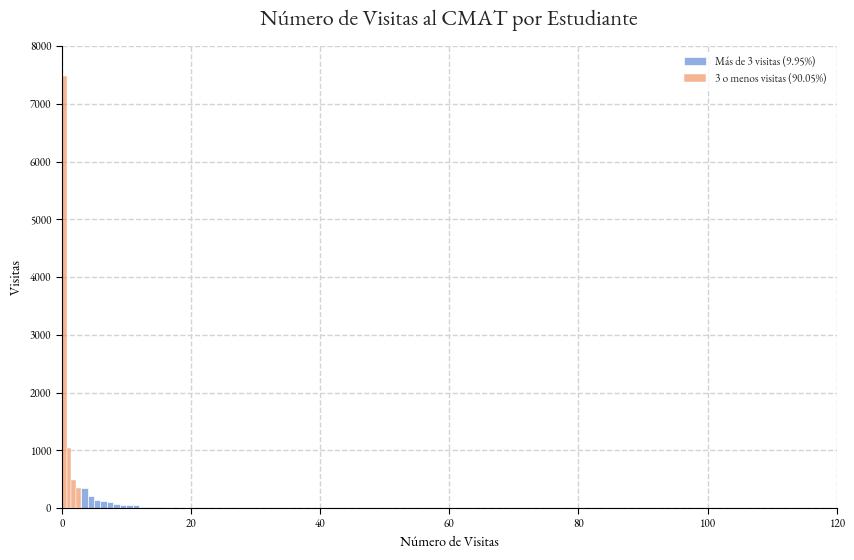

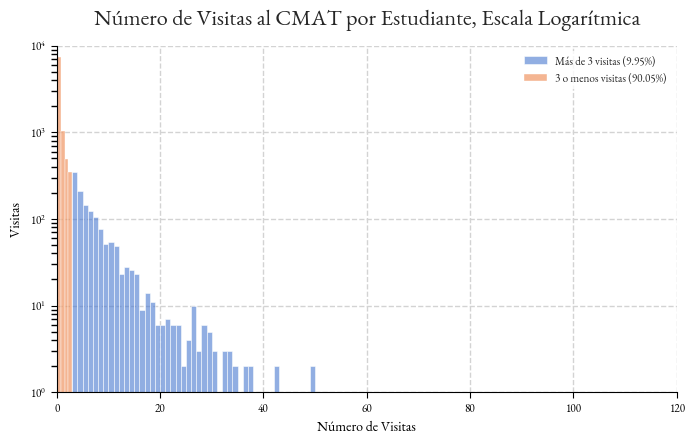

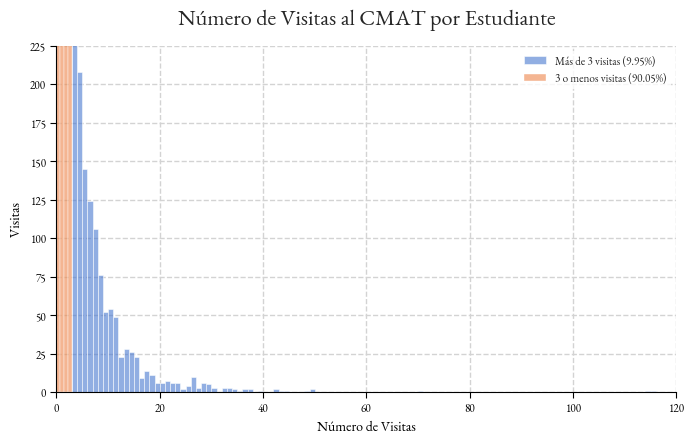

In [12]:
def plot_asesorias_distribution(asesoria_counts: pd.Series):
    # density of VISITAS column
    # count the percentage of students with more than 3 visits
    total_students = asesoria_counts.count()
    num_more_than_3 = (asesoria_counts > 3).sum()
    percentage_more_than_3 = (num_more_than_3 / total_students) * 100
    
    plt.figure(figsize=(10, 6))


    sns.histplot(asesoria_counts[asesoria_counts >= 3], bins=asesoria_counts.max()-3,  alpha=0.6, label=f'Más de 3 visitas ({percentage_more_than_3:.2f}%)')
    sns.histplot(asesoria_counts[asesoria_counts <= 3], bins=4,  alpha=0.6, label=f'3 o menos visitas ({100-percentage_more_than_3:.2f}%)')
    plt.title('Número de Visitas al CMAT por Estudiante')
    plt.xlabel('Número de Visitas')
    plt.ylabel('Visitas')
    plt.savefig('visualizations/figuras/03_01.pdf', bbox_inches='tight')
    plt.legend()
    plt.show()
    
    # density of VISITAS column with log scale
    sns.histplot(asesoria_counts[asesoria_counts >= 3], bins=asesoria_counts.max()-3,  alpha=0.6, label=f'Más de 3 visitas ({percentage_more_than_3:.2f}%)')
    sns.histplot(asesoria_counts[asesoria_counts <= 3], bins=4,  alpha=0.6, label=f'3 o menos visitas ({100-percentage_more_than_3:.2f}%)')
    plt.title('Número de Visitas al CMAT por Estudiante, Escala Logarítmica')
    plt.xlabel('Número de Visitas')
    plt.ylabel('Visitas')
    plt.yscale('log')
    # plt.savefig('visualizations/figuras/03_01.pdf', bbox_inches='tight')
    plt.legend()
    plt.show()

    # density of VISITAS column
    sns.histplot(asesoria_counts[asesoria_counts >= 3], bins=asesoria_counts.max()-3,  alpha=0.6, label=f'Más de 3 visitas ({percentage_more_than_3:.2f}%)')
    sns.histplot(asesoria_counts[asesoria_counts <= 3], bins=4,  alpha=0.6, label=f'3 o menos visitas ({100-percentage_more_than_3:.2f}%)')
    plt.title('Número de Visitas al CMAT por Estudiante')
    plt.xlabel('Número de Visitas')
    plt.ylabel('Visitas')
    plt.legend()
    plt.ylim(0, 225)
    plt.savefig('visualizations/figuras/03_02.pdf', bbox_inches='tight')
    plt.show()

plot_asesorias_distribution(asesoria_counts)

In [13]:
# if the id of asesorias_counts is in materias['CLAVEALUMNO'], map the count to a new column 'VISITAS' in materias
materias['VISITAS'] = materias['CLAVEALUMNO'].map(asesoria_counts)

# add the timmes each id appears as a new column 'asesoria_count' in asesorias
materias['VISITAS'] = materias['VISITAS'].fillna(0).astype(int)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815,3
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109,3
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085,0
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152,49
...,...,...,...,...,...,...,...,...,...
26403,403107,INT,2019,OTOÑO,MAT1022,CÁLCULO I,8,23453,0
26413,403205,INT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.5,23897,0
26546,403514,INT,2021,OTOÑO,MAT1022,CÁLCULO I,8.8,22446,0
26547,403514,INT,2022,PRIMAVERA,MAT2012,CÁLCULO II,8.1,23149,0


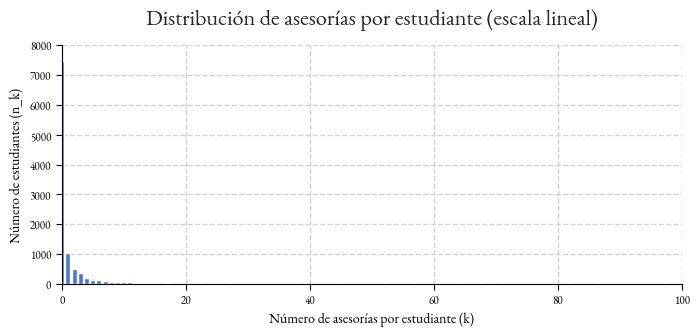

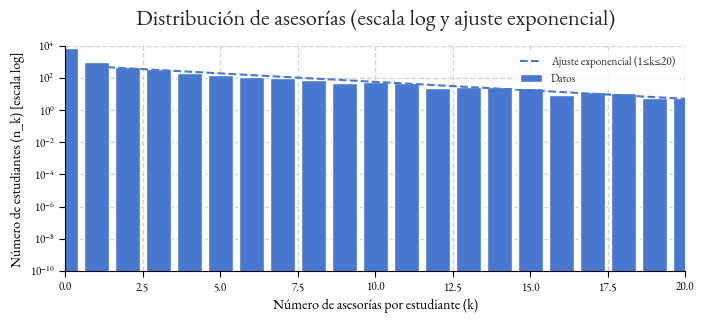

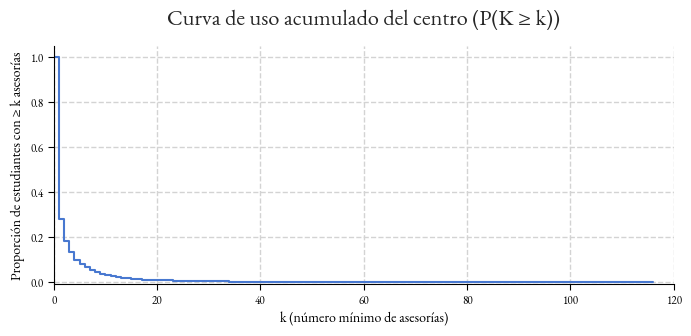

71.9% de los estudiantes nunca usa el centro (k=0); 28.1% lo usa al menos una vez. La media global es E[K]=1.23, pero entre usuarios E[K | K≥1]=4.39. Solo ≈8.0% de los estudiantes realizan ≥5 asesorías. La distribución es fuertemente asimétrica y concentrada en k bajos. Para 1≤k≤20, los puntos en escala log son casi lineales, lo que indica una caída aproximadamente exponencial en el número de estudiantes. Modelo log-lineal (1≤k≤20): log n_k ≈ 6.484 + -0.243 k,  R²=0.962. Retención por sesión q=exp(β)≈0.784, vida media≈2.85 asesorías. Las desviaciones para k grandes se deben a la cola muy escasa (pocos alumnos). La proporción de alumnos con muchas asesorías cae rápido: la mayoría realiza pocas sesiones y solo una fracción muy pequeña llega a valores altos de k. Entre usuarios (K≥1), aproximadamente la mitad deja de asistir antes de k≈3 asesorías. Esta curva es compatible con un modelo geométrico de retención con probabilidad de continuidad cercana a q.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 0. Load and prepare data (adapt paths as needed)
# -------------------------------------------------------------------
# asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')
# materias  = pd.read_excel('data/onedrive/Archivos2024/Materias2024.xlsx')

asesorias['fecha'] = pd.to_datetime(asesorias['fecha'], errors='coerce')

# Conteo de asesorías por alumno
asesoria_counts = asesorias['id'].value_counts()

# Incluye alumnos que nunca usaron el centro (0 asesorías)
asesoria_counts = asesoria_counts.reindex(
    materias['CLAVEALUMNO'].unique(),
    fill_value=0
)

# Frecuencia: cuántos alumnos tuvieron k asesorías
freq = asesoria_counts.value_counts().sort_index()
k_values = freq.index.to_numpy()
n_values = freq.values
N = n_values.sum()

# Estadísticos básicos
p_zero = n_values[0] / N                    # P(K=0)
mean_all = (k_values * n_values).sum() / N  # E[K]
mean_users = (k_values[1:] * n_values[1:]).sum() / (N - n_values[0])

p_ge_1 = 1 - p_zero
p_ge_5 = (asesoria_counts >= 5).mean()

# -------------------------------------------------------------------
# 1. Plot 1: Distribución en escala lineal
# -------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(16/2, 9/2))
ax1.bar(k_values, n_values)
ax1.set_xlabel("Número de asesorías por estudiante (k)")
ax1.set_ylabel("Número de estudiantes (n_k)")
ax1.set_title("Distribución de asesorías por estudiante (escala lineal)")

fig1.subplots_adjust(bottom=0.35)

interp1 = (
    f"{p_zero:.1%} de los estudiantes nunca usa el centro (k=0); "
    f"{p_ge_1:.1%} lo usa al menos una vez. "
    f"La media global es E[K]={mean_all:.2f}, "
    f"pero entre usuarios E[K | K≥1]={mean_users:.2f}."
)

interp1_tech = (
    f"Solo ≈{p_ge_5:.1%} de los estudiantes realizan ≥5 asesorías. "
    "La distribución es fuertemente asimétrica y concentrada en k bajos."
)

# xlim from 0 to 100
ax1.set_xlim(0, 100)


plt.show()

# -------------------------------------------------------------------
# 2. Plot 2: Escala log + ajuste exponencial en 1 ≤ k ≤ k_fit_max
# -------------------------------------------------------------------
k_fit_max = 20  # ventana donde hay suficientes datos para ajustar

mask_fit = (k_values >= 1) & (k_values <= k_fit_max)
x_fit = k_values[mask_fit].astype(float)
y_fit = np.log(n_values[mask_fit].astype(float))

# Ajuste log-lineal: log n_k ≈ alpha + beta * k
beta, alpha = np.polyfit(x_fit, y_fit, deg=1)

# Métricas del ajuste
y_hat = alpha + beta * x_fit
ss_res = np.sum((y_fit - y_hat) ** 2)
ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

q = np.exp(beta)  # factor de retención por “salto” en k
half_life = np.log(0.5) / np.log(q)  # vida media en número de asesorías

# Curva ajustada extendida en todo el rango
x_line = np.linspace(1, k_values.max(), 300)
n_line = np.exp(alpha + beta * x_line)

fig2, ax2 = plt.subplots(figsize=(16/2, 9/2))
ax2.bar(k_values, n_values, label="Datos")
ax2.plot(x_line, n_line, linestyle="--", marker="",
         label="Ajuste exponencial (1≤k≤20)")
ax2.set_yscale("log")
ax2.set_xlim(0, k_fit_max)  # zoom en la zona donde el ajuste funciona bien
ax2.set_xlabel("Número de asesorías por estudiante (k)")
ax2.set_ylabel("Número de estudiantes (n_k) [escala log]")
ax2.set_title("Distribución de asesorías (escala log y ajuste exponencial)")
ax2.legend()

fig2.subplots_adjust(bottom=0.38)

interp2 = (
    "Para 1≤k≤20, los puntos en escala log son casi lineales, lo que indica "
    "una caída aproximadamente exponencial en el número de estudiantes."
)

interp2_tech = (
    "Modelo log-lineal (1≤k≤20): log n_k ≈ "
    f"{alpha:.3f} + {beta:.3f} k,  R²={r2:.3f}. "
    f"Retención por sesión q=exp(β)≈{q:.3f}, vida media≈{half_life:.2f} asesorías. "
    "Las desviaciones para k grandes se deben a la cola muy escasa (pocos alumnos)."
)



plt.show()

# -------------------------------------------------------------------
# 3. Plot 3: Curva de cola P(K ≥ k) (supervivencia discreta)
# -------------------------------------------------------------------
k_max = int(k_values.max())
k_grid = np.arange(0, k_max + 1)
tail_probs = np.array([(asesoria_counts >= k).mean() for k in k_grid])

# Condicional en usuarios (K≥1) para vida media
cond_counts = asesoria_counts[asesoria_counts >= 1]
k_grid_pos = np.arange(1, cond_counts.max() + 1)
tail_cond = np.array([(cond_counts >= k).mean() for k in k_grid_pos])
half_idx = np.where(tail_cond <= 0.5)[0]
k_half = k_grid_pos[half_idx[0]] if len(half_idx) > 0 else np.nan

fig3, ax3 = plt.subplots(figsize=(16/2, 9/2))
ax3.step(k_grid, tail_probs, where="post")
ax3.set_xlabel("k (número mínimo de asesorías)")
ax3.set_ylabel("Proporción de estudiantes con ≥ k asesorías")
ax3.set_title("Curva de uso acumulado del centro (P(K ≥ k))")
ax3.set_ylim(-0.01, 1.05)

fig3.subplots_adjust(bottom=0.35)

interp3 = (
    "La proporción de alumnos con muchas asesorías cae rápido: "
    "la mayoría realiza pocas sesiones y solo una fracción muy pequeña "
    "llega a valores altos de k."
)

interp3_tech = (
    "Entre usuarios (K≥1), aproximadamente la mitad deja de asistir antes de "
    f"k≈{k_half} asesorías. Esta curva es compatible con un modelo geométrico "
    "de retención con probabilidad de continuidad cercana a q."
)



plt.show()

print(interp1, interp1_tech, interp2, interp2_tech, interp3, interp3_tech)


In [15]:
# -------------------------------------------------------------------
# 4. Texto integrado (interpretación + resumen matemático)
# -------------------------------------------------------------------
texto = (
    f"{p_zero:.1%} de los estudiantes nunca usa el centro (K=0) y \n"
    f"{p_ge_1:.1%} lo usa al menos una vez. \n"
    f"La media global es E[K]={mean_all:.2f}, \n"
    f"pero entre usuarios E[K | K≥1]={mean_users:.2f}. \n"
    f"Solo ≈{p_ge_5:.1%} de los estudiantes realizan ≥5 asesorías, \n"
    "por lo que la distribución es fuertemente asimétrica y concentrada en \n"
    "valores bajos de K. \n"
    f"Para 1≤K≤{k_fit_max}, los puntos en escala log son casi lineales, \n"
    "lo que indica una caída aproximadamente exponencial en el número de \n"
    "estudiantes. El modelo log-lineal (logaritmo natural) en ese rango es \n"
    f"log n_k ≈ {alpha:.3f} + {beta:.3f} k con R²={r2:.3f}. \n"
    f"De aquí se obtiene una retención por sesión q=exp(β)≈{q:.3f} \n"
    f"y una vida media de ≈{half_life:.2f} asesorías. \n"
    "Las desviaciones para K grandes se deben a que la cola tiene muy pocos \n"
    "alumnos. La proporción de alumnos con muchas asesorías cae rápido: \n"
    "la mayoría realiza pocas sesiones y solo una fracción muy pequeña \n"
    "alcanza valores altos de K. \n"
    f"Entre usuarios (K≥1), aproximadamente la mitad deja de asistir antes de \n"
    f"K≈{k_half:.0f} asesorías, lo que es compatible con un modelo geométrico \n"
    f"de retención con probabilidad de continuidad cercana a q = {q:.3f}.\n"
)

resumen = (
    "Resumen matemático: \n"
    f"log n_k ≈ {alpha:.3f} + {beta:.3f} k; \n"
    f"q = exp(β) ≈ {q:.3f}; \n"
    f"E[K]={mean_all:.2f}; \n"
    f"E[K | K≥1]={mean_users:.2f}."
)

print(texto + "\n\n" + resumen)


71.9% de los estudiantes nunca usa el centro (K=0) y 
28.1% lo usa al menos una vez. 
La media global es E[K]=1.23, 
pero entre usuarios E[K | K≥1]=4.39. 
Solo ≈8.0% de los estudiantes realizan ≥5 asesorías, 
por lo que la distribución es fuertemente asimétrica y concentrada en 
valores bajos de K. 
Para 1≤K≤20, los puntos en escala log son casi lineales, 
lo que indica una caída aproximadamente exponencial en el número de 
estudiantes. El modelo log-lineal (logaritmo natural) en ese rango es 
log n_k ≈ 6.484 + -0.243 k con R²=0.962. 
De aquí se obtiene una retención por sesión q=exp(β)≈0.784 
y una vida media de ≈2.85 asesorías. 
Las desviaciones para K grandes se deben a que la cola tiene muy pocos 
alumnos. La proporción de alumnos con muchas asesorías cae rápido: 
la mayoría realiza pocas sesiones y solo una fracción muy pequeña 
alcanza valores altos de K. 
Entre usuarios (K≥1), aproximadamente la mitad deja de asistir antes de 
K≈3 asesorías, lo que es compatible con un modelo ge

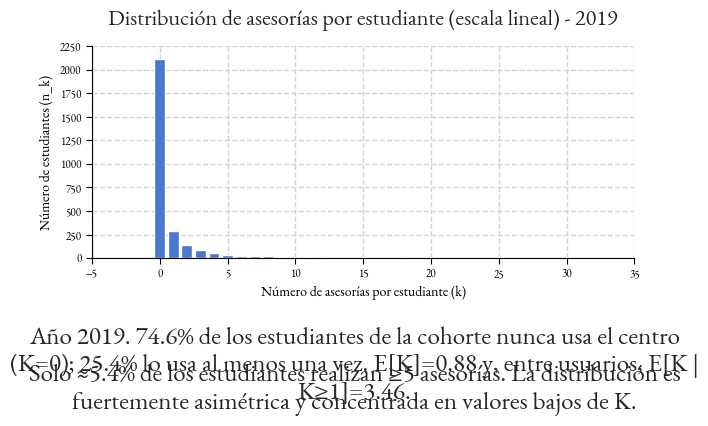

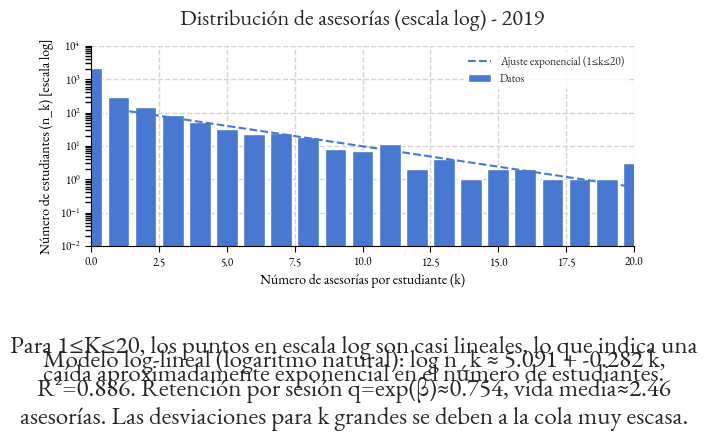

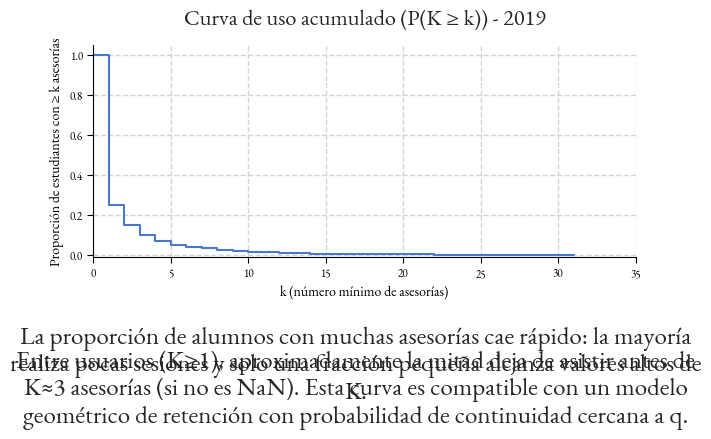

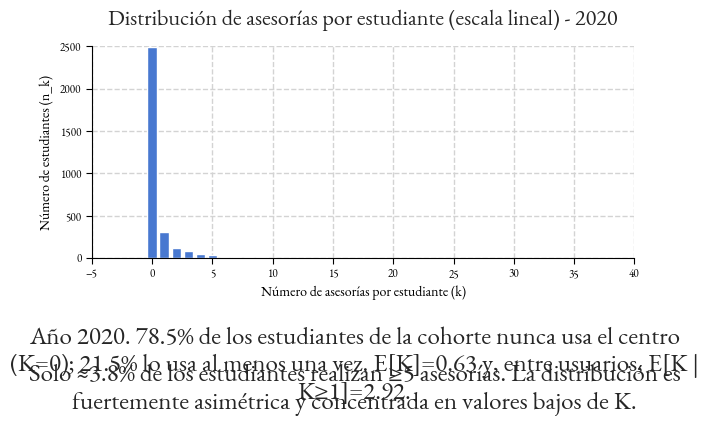

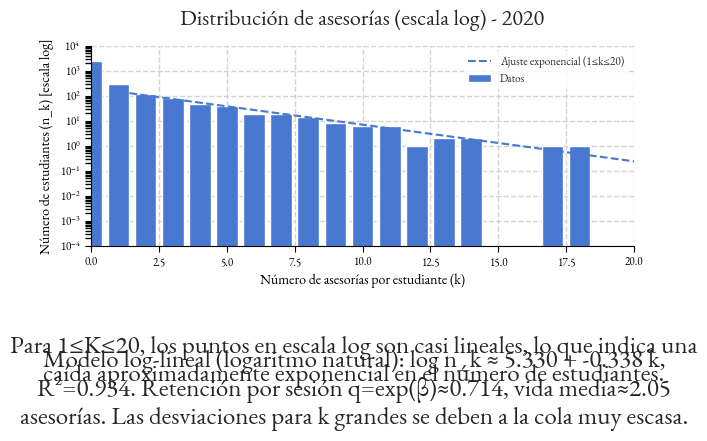

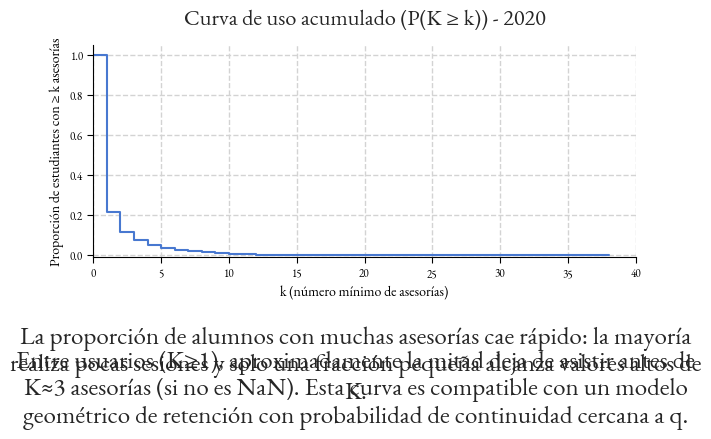

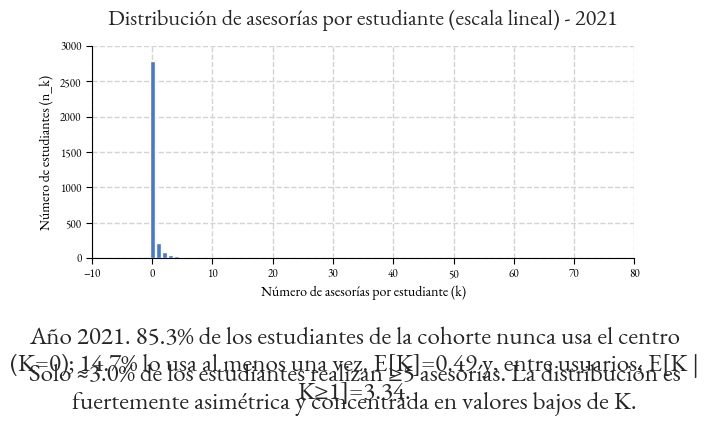

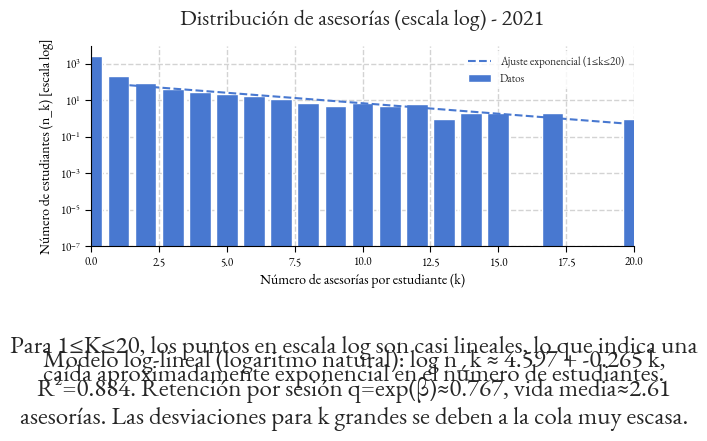

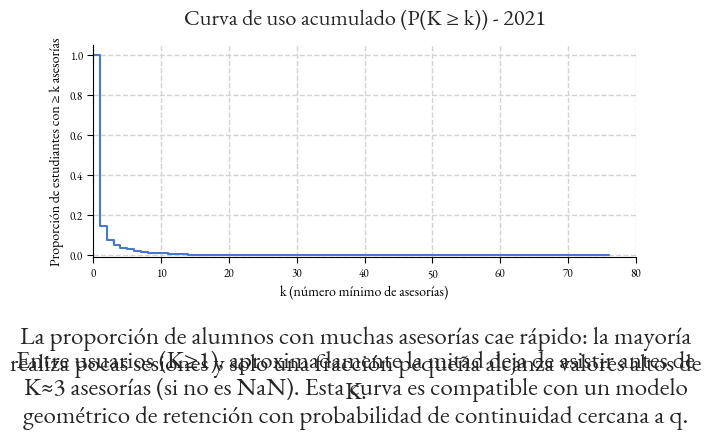

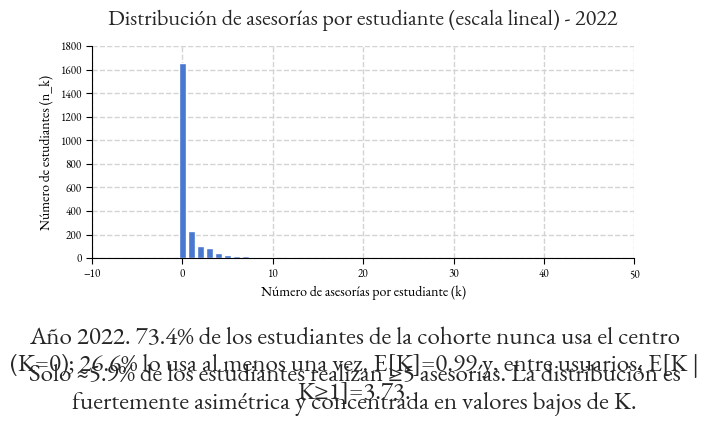

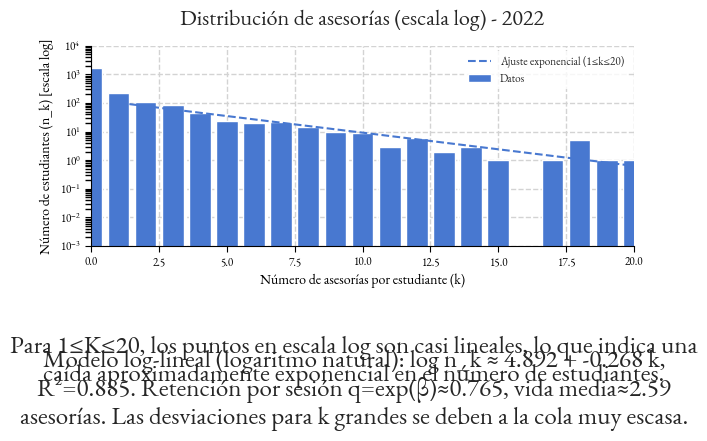

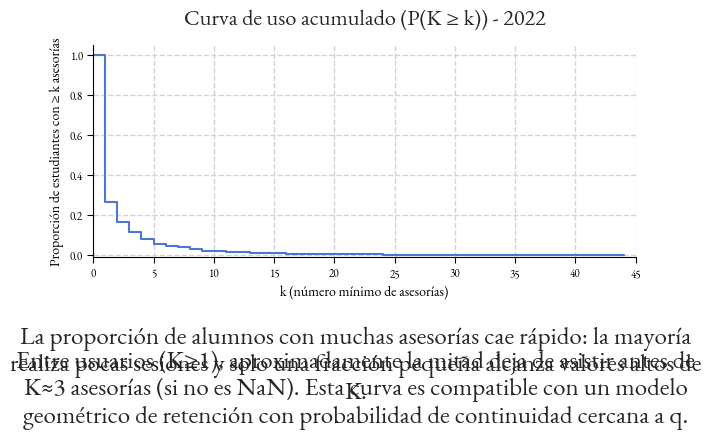

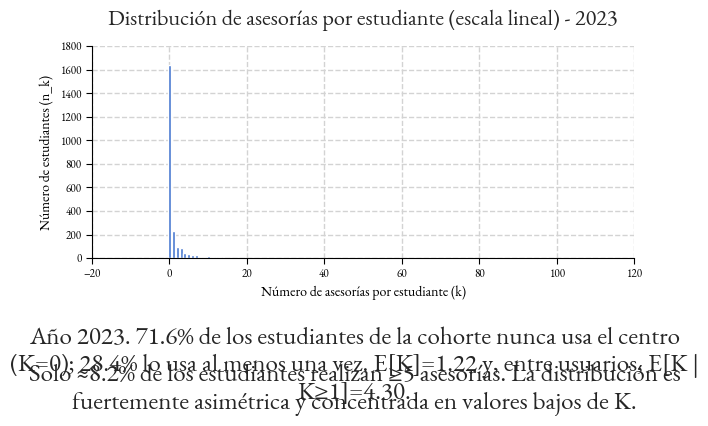

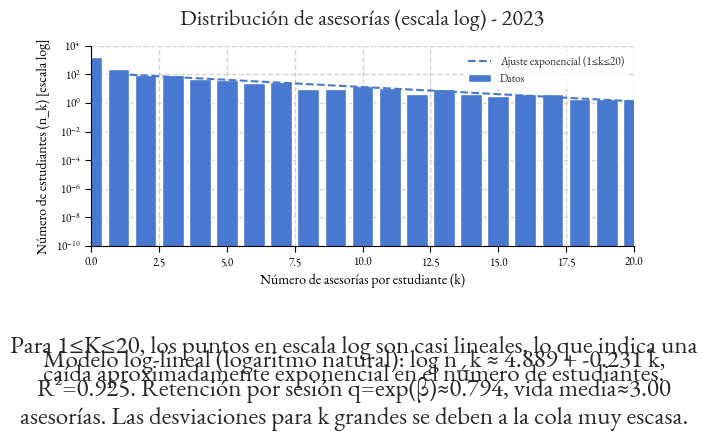

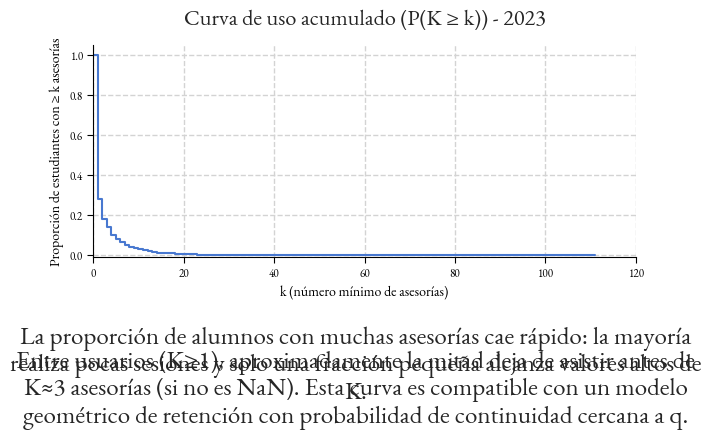

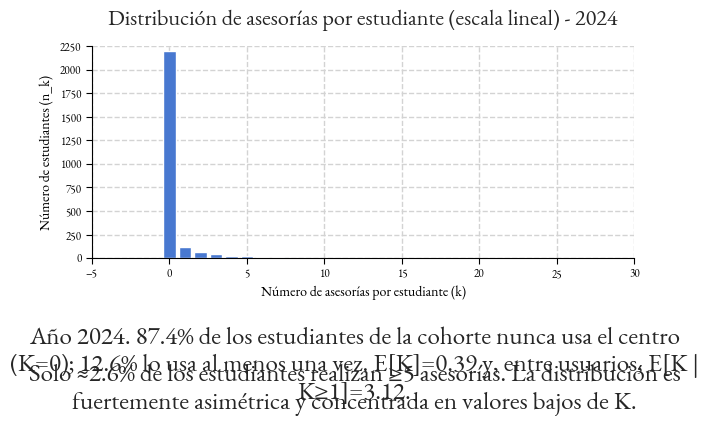

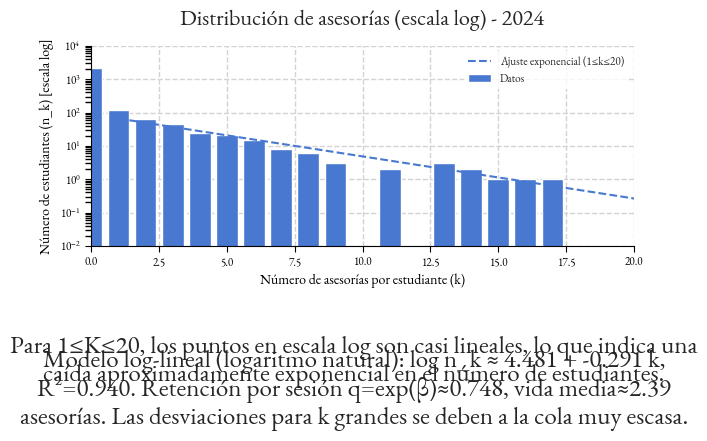

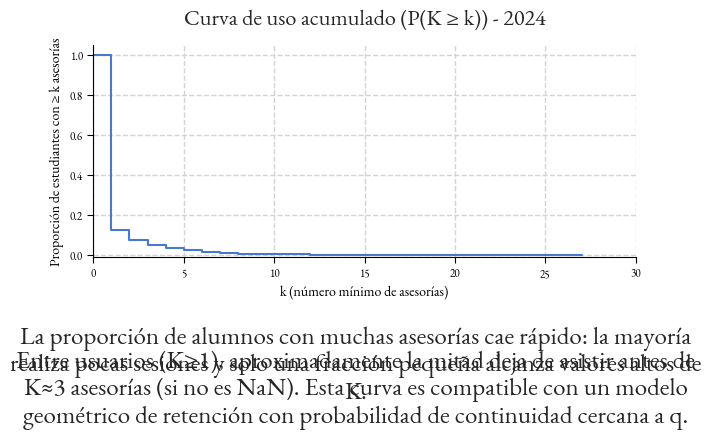

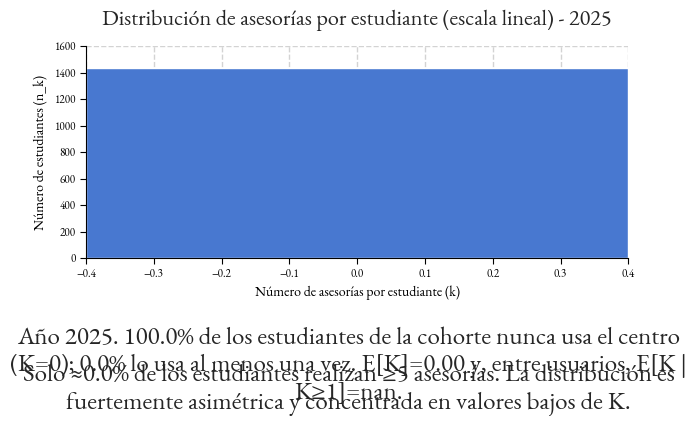

C:\Users\herie\AppData\Local\Temp\ipykernel_26412\2162039820.py:128: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax2.set_xlim(0, min(k_fit_max, k_max))


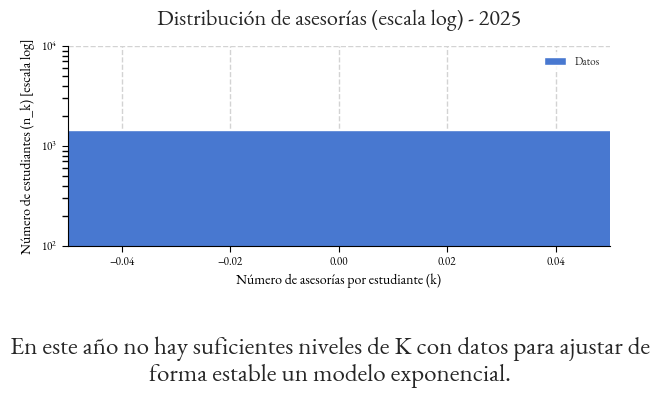

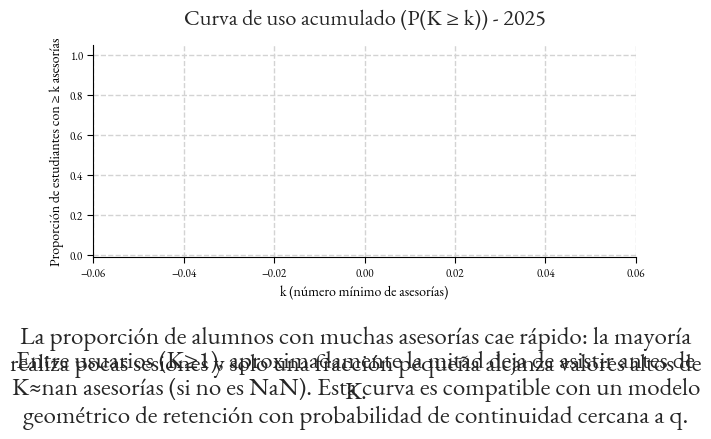

      N_students    p_zero    p_ge_1  mean_all  mean_users    p_ge_5  \
year                                                                   
2019        2827  0.746021  0.253979  0.878670    3.459610  0.054121   
2020        3175  0.784567  0.215433  0.628031    2.915205  0.038425   
2021        3265  0.853292  0.146708  0.490352    3.342380  0.029709   
2022        2256  0.733599  0.266401  0.993351    3.728785  0.059397   
2023        2287  0.716222  0.283778  1.219502    4.297381  0.081767   
2024        2518  0.874106  0.125894  0.393169    3.123028  0.025814   
2025        1438  1.000000  0.000000  0.000000         NaN  0.000000   

         alpha      beta        r2         q  half_life  k_half  
year                                                             
2019  5.090996 -0.281742  0.885606  0.754468   2.460217     3.0  
2020  5.330168 -0.337569  0.933747  0.713503   2.053351     3.0  
2021  4.596700 -0.265193  0.883704  0.767058   2.613745     3.0  
2022  4.892389 -0.267

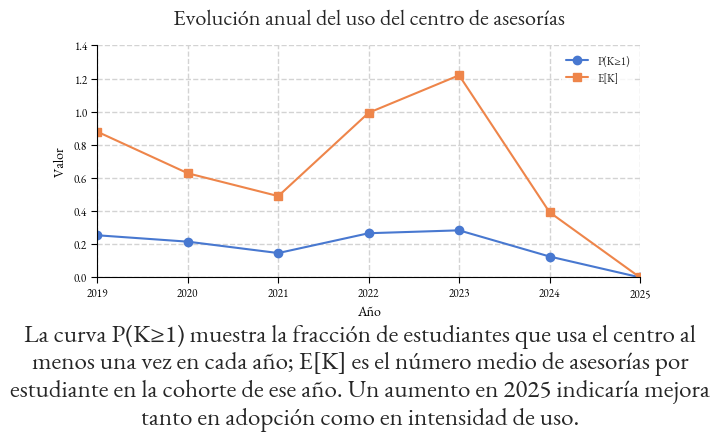

Año 2019: P(K=0)=74.6%, P(K≥1)=25.4%, E[K]=0.88, E[K|K≥1]=3.46, q≈0.754 (si definido).
Año 2020: P(K=0)=78.5%, P(K≥1)=21.5%, E[K]=0.63, E[K|K≥1]=2.92, q≈0.714 (si definido).
Año 2021: P(K=0)=85.3%, P(K≥1)=14.7%, E[K]=0.49, E[K|K≥1]=3.34, q≈0.767 (si definido).
Año 2022: P(K=0)=73.4%, P(K≥1)=26.6%, E[K]=0.99, E[K|K≥1]=3.73, q≈0.765 (si definido).
Año 2023: P(K=0)=71.6%, P(K≥1)=28.4%, E[K]=1.22, E[K|K≥1]=4.30, q≈0.794 (si definido).
Año 2024: P(K=0)=87.4%, P(K≥1)=12.6%, E[K]=0.39, E[K|K≥1]=3.12, q≈0.748 (si definido).
Año 2025: P(K=0)=100.0%, P(K≥1)=0.0%, E[K]=0.00, E[K|K≥1]=nan, q≈nan (si definido).

Comparación 2024 vs 2025:
- P(K≥1) pasó de 12.6% a 0.0%.
- E[K] pasó de 0.39 a 0.00.
- E[K|K≥1] pasó de 3.12 a nan.
- q pasó de ≈0.748 a ≈nan (si ambos definidos).


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Preparar datos
# -------------------------------------------------------------------
asesorias['fecha'] = pd.to_datetime(asesorias['fecha'], errors='coerce')

# Definimos años a analizar (ajusta si quieres otro rango)
years = list(range(2019, 2026))  # 2019–2025

k_fit_max = 20   # rango para el ajuste log-lineal
cohort_rows = [] # aquí guardaremos el resumen por año

# -------------------------------------------------------------------
# Función de análisis por año
# -------------------------------------------------------------------
for year in years:
    # Cohorte = alumnos que tienen al menos una materia en ese año
    cohort_students = materias.loc[materias['anio'] == year, 'CLAVEALUMNO'].unique()
    if len(cohort_students) == 0:
        print(f"Año {year}: sin alumnos en 'materias', se omite.")
        continue

    # Asesorías realizadas en ese año
    ases_year = asesorias.loc[asesorias['fecha'].dt.year == year]

    # Conteo de asesorías por alumno (solo en ese año)
    counts = ases_year['id'].value_counts()
    counts = counts.reindex(cohort_students, fill_value=0)

    # Distribución de K (número de asesorías)
    freq = counts.value_counts().sort_index()
    k_values = freq.index.to_numpy()
    n_values = freq.values
    N = n_values.sum()

    # Aseguramos que exista k=0 en el índice
    n_zero = freq.loc[0] if 0 in freq.index else 0
    p_zero = n_zero / N
    p_ge_1 = 1 - p_zero

    mean_all = (k_values * n_values).sum() / N
    if p_ge_1 > 0:
        mean_users = (k_values[k_values >= 1] * n_values[k_values >= 1]).sum() / (N - n_zero)
    else:
        mean_users = np.nan

    p_ge_5 = (counts >= 5).mean()

    # ---------------------------------------------------------------
    # Ajuste log-lineal log n_k ≈ alpha + beta k en 1 ≤ k ≤ k_fit_max
    # ---------------------------------------------------------------
    mask_fit = (k_values >= 1) & (k_values <= k_fit_max) & (n_values > 0)
    if mask_fit.sum() >= 2:
        x_fit = k_values[mask_fit].astype(float)
        y_fit = np.log(n_values[mask_fit].astype(float))

        beta, alpha = np.polyfit(x_fit, y_fit, deg=1)

        y_hat = alpha + beta * x_fit
        ss_res = np.sum((y_fit - y_hat) ** 2)
        ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        q = np.exp(beta)
        half_life = np.log(0.5) / np.log(q) if (q > 0) and (q != 1) else np.nan
    else:
        alpha = beta = r2 = q = half_life = np.nan

    # ---------------------------------------------------------------
    # Curva de cola P(K ≥ k) y vida media condicional por conteo
    # ---------------------------------------------------------------
    k_max = int(k_values.max())
    k_grid = np.arange(0, k_max + 1)
    tail_probs = np.array([(counts >= k).mean() for k in k_grid])

    cond_counts = counts[counts >= 1]
    if cond_counts.size >= 1:
        k_grid_pos = np.arange(1, cond_counts.max() + 1)
        tail_cond = np.array([(cond_counts >= k).mean() for k in k_grid_pos])
        half_idx = np.where(tail_cond <= 0.5)[0]
        k_half = k_grid_pos[half_idx[0]] if len(half_idx) > 0 else np.nan
    else:
        k_half = np.nan

    # ===============================================================
    # Gráfica 1: Distribución en escala lineal
    # ===============================================================
    fig1, ax1 = plt.subplots(figsize=(7, 4))
    ax1.bar(k_values, n_values)
    ax1.set_xlabel("Número de asesorías por estudiante (k)")
    ax1.set_ylabel("Número de estudiantes (n_k)")
    ax1.set_title(f"Distribución de asesorías por estudiante (escala lineal) - {year}")

    fig1.subplots_adjust(bottom=0.35)

    interp1 = (
        f"Año {year}. {p_zero:.1%} de los estudiantes de la cohorte nunca usa el centro (K=0); "
        f"{p_ge_1:.1%} lo usa al menos una vez. E[K]={mean_all:.2f} y, "
        f"entre usuarios, E[K | K≥1]={mean_users:.2f}."
    )

    interp1_tech = (
        f"Solo ≈{p_ge_5:.1%} de los estudiantes realizan ≥5 asesorías. "
        "La distribución es fuertemente asimétrica y concentrada en valores bajos de K."
    )

    fig1.text(0.5, 0.08, interp1, ha="center", va="center", wrap=True)
    fig1.text(0.5, 0.02, interp1_tech, ha="center", va="center", wrap=True)

    plt.show()

    # ===============================================================
    # Gráfica 2: Escala log + ajuste exponencial
    # ===============================================================
    fig2, ax2 = plt.subplots(figsize=(7, 4))
    ax2.bar(k_values, n_values, label="Datos")

    if not np.isnan(alpha):
        x_line = np.linspace(1, k_max, 300)
        n_line = np.exp(alpha + beta * x_line)
        ax2.plot(x_line, n_line, linestyle="--", marker="",
                 label=f"Ajuste exponencial (1≤k≤{k_fit_max})")

    ax2.set_yscale("log")
    ax2.set_xlim(0, min(k_fit_max, k_max))
    ax2.set_xlabel("Número de asesorías por estudiante (k)")
    ax2.set_ylabel("Número de estudiantes (n_k) [escala log]")
    ax2.set_title(f"Distribución de asesorías (escala log) - {year}")
    ax2.legend()

    fig2.subplots_adjust(bottom=0.38)

    if not np.isnan(alpha):
        interp2 = (
            f"Para 1≤K≤{k_fit_max}, los puntos en escala log son casi lineales, "
            "lo que indica una caída aproximadamente exponencial en el número de estudiantes."
        )

        interp2_tech = (
            "Modelo log-lineal (logaritmo natural): "
            f"log n_k ≈ {alpha:.3f} + {beta:.3f} k, R²={r2:.3f}. "
            f"Retención por sesión q=exp(β)≈{q:.3f}, vida media≈{half_life:.2f} asesorías. "
            "Las desviaciones para k grandes se deben a la cola muy escasa."
        )
    else:
        interp2 = (
            "En este año no hay suficientes niveles de K con datos "
            "para ajustar de forma estable un modelo exponencial."
        )
        interp2_tech = ""

    fig2.text(0.5, 0.09, interp2, ha="center", va="center", wrap=True)
    fig2.text(0.5, 0.02, interp2_tech, ha="center", va="center", wrap=True)

    plt.show()

    # ===============================================================
    # Gráfica 3: Curva de cola P(K ≥ k)
    # ===============================================================
    fig3, ax3 = plt.subplots(figsize=(7, 4))
    ax3.step(k_grid, tail_probs, where="post")
    ax3.set_xlabel("k (número mínimo de asesorías)")
    ax3.set_ylabel("Proporción de estudiantes con ≥ k asesorías")
    ax3.set_title(f"Curva de uso acumulado (P(K ≥ k)) - {year}")
    ax3.set_ylim(-0.01, 1.05)

    fig3.subplots_adjust(bottom=0.35)

    interp3 = (
        "La proporción de alumnos con muchas asesorías cae rápido: "
        "la mayoría realiza pocas sesiones y solo una fracción pequeña "
        "alcanza valores altos de K."
    )

    interp3_tech = (
        "Entre usuarios (K≥1), aproximadamente la mitad deja de asistir antes de "
        f"K≈{k_half:.0f} asesorías (si no es NaN). "
        "Esta curva es compatible con un modelo geométrico de retención "
        "con probabilidad de continuidad cercana a q."
    )

    fig3.text(0.5, 0.08, interp3, ha="center", va="center", wrap=True)
    fig3.text(0.5, 0.02, interp3_tech, ha="center", va="center", wrap=True)

    plt.show()

    # ---------------------------------------------------------------
    # Guardar resumen numérico del año
    # ---------------------------------------------------------------
    cohort_rows.append({
        "year": year,
        "N_students": N,
        "p_zero": p_zero,
        "p_ge_1": p_ge_1,
        "mean_all": mean_all,
        "mean_users": mean_users,
        "p_ge_5": p_ge_5,
        "alpha": alpha,
        "beta": beta,
        "r2": r2,
        "q": q,
        "half_life": half_life,
        "k_half": k_half,
    })

# -------------------------------------------------------------------
# Resumen por año en un DataFrame
# -------------------------------------------------------------------
cohort_summary = pd.DataFrame(cohort_rows).set_index("year").sort_index()
print(cohort_summary)

# -------------------------------------------------------------------
# Gráfica de mejora por año (ejemplo: porcentaje que usa el centro)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cohort_summary.index, cohort_summary['p_ge_1'], marker="o", label="P(K≥1)")
ax.plot(cohort_summary.index, cohort_summary['mean_all'], marker="s", label="E[K]")
ax.set_xlabel("Año")
ax.set_ylabel("Valor")
ax.set_title("Evolución anual del uso del centro de asesorías")
ax.legend()

fig.subplots_adjust(bottom=0.30)

interp_global = (
    "La curva P(K≥1) muestra la fracción de estudiantes que usa el centro "
    "al menos una vez en cada año; E[K] es el número medio de asesorías por "
    "estudiante en la cohorte de ese año. Un aumento en 2025 indicaría "
    "mejora tanto en adopción como en intensidad de uso."
)

fig.text(0.5, 0.05, interp_global, ha="center", va="center", wrap=True)

plt.show()

# -------------------------------------------------------------------
# Texto automático por año + comparación específica de 2025
# -------------------------------------------------------------------
lineas = []
for y, row in cohort_summary.iterrows():
    lineas.append(
        f"Año {y}: P(K=0)={row['p_zero']:.1%}, P(K≥1)={row['p_ge_1']:.1%}, "
        f"E[K]={row['mean_all']:.2f}, E[K|K≥1]={row['mean_users']:.2f}, "
        f"q≈{row['q']:.3f} (si definido)."
    )

texto_todos_anios = "\n".join(lineas)
print(texto_todos_anios)

# Comparar 2025 con el último año anterior disponible
if 2025 in cohort_summary.index:
    prev_years = cohort_summary.index[cohort_summary.index < 2025]
    if len(prev_years) > 0:
        y_prev = prev_years.max()
        row_prev = cohort_summary.loc[y_prev]
        row_2025 = cohort_summary.loc[2025]

        texto_2025 = (
            f"Comparación {y_prev} vs 2025:\n"
            f"- P(K≥1) pasó de {row_prev['p_ge_1']:.1%} a {row_2025['p_ge_1']:.1%}.\n"
            f"- E[K] pasó de {row_prev['mean_all']:.2f} a {row_2025['mean_all']:.2f}.\n"
            f"- E[K|K≥1] pasó de {row_prev['mean_users']:.2f} a {row_2025['mean_users']:.2f}.\n"
            f"- q pasó de ≈{row_prev['q']:.3f} a ≈{row_2025['q']:.3f} (si ambos definidos)."
        )
        print("\n" + texto_2025)
